# Orçamento LOA Florianópolis 2026

Análise estratégica e fiscal da Lei Orçamentária Anual (LOA) de Florianópolis para 2026.
O notebook executa a carga e o tratamento dos dados, gera gráficos analíticos sobre
receitas e despesas e simula o monitoramento de conformidade com a Lei de Responsabilidade Fiscal (LRF).


### Resumo do Orçamento Consolidado 2026

| Categoria | Subcategoria | Especificação | Receita (R$) | Despesa (R$) |
| :--- | :--- | :--- | :---: | :---: |
| **Receitas Correntes** | Impostos, Taxas e Contribuições | **Total da Categoria** | 2.170.642.220,00 |  |
|  |  | *IPTU* | 558.500.211,00 |  |
|  |  | *ISSQN* | 994.682.735,00 |  |
|  |  | *ITBI* | 183.074.670,00 |  |
|  |  | *IRRF* | 206.297.845,00 |  |
| **Receitas Correntes** | Transferências Correntes | **Total da Categoria** | 1.519.498.970,00 |  |
|  |  | *Cota-Parte do FPM* | 328.183.364,00 |  |
|  |  | *Cota-Parte do ICMS* | 275.813.540,00 |  |
|  |  | *Cota-Parte do IPVA* | 220.263.224,00 |  |
|  |  | *Transferências do FUNDEB* | 408.020.050,00 |  |
| **Receitas Correntes** | *(+) Outras Rubricas Correntes* | *Contribuições, Serviços, Patrimonial* | 325.563.614,00 |  |
| **Deduções da Receita** | Deduções (II) | **Total Deduções (FUNDEB/RPPS)** | -273.303.424,00 |  |
| **Receitas de Capital** | Transferências/Outros | **Total de Capital** | 52.939.780,00 |  |
| **Receitas Intra-Orçamentárias** | Receitas Intra-Orçamentárias | **Total Intra** | 201.562.355,00 |  |
| **Despesas Correntes** | Pessoal e Encargos Sociais | **Total da Categoria (Excl. Intra)** |  | 2.091.148.171,00 |
| **Despesas Correntes** | Juros e Encargos da Dívida | **Total da Categoria (Excl. Intra)** |  | 130.556.349,00 |
| **Despesas Correntes** | Outras Despesas Correntes | **Total da Categoria (Excl. Intra)** |  | 1.363.857.903,63 |
| **Despesas de Capital** | Investimentos/Amortização | **Total de Capital (Excl. Intra)** |  | 448.714.159,37 |
| **Reserva** | Reserva de Contingência | **Total Reserva** |  | 19.416.154,00 |
| **Intra-Orçamentárias** | Despesas Intra-Orçamentárias | **Total Intra (Pessoal/Dívida/Outros)** |  | 216.514.202,00 |
| **TOTAIS GERAIS** | **TOTAL GERAL** | **Orçamento Consolidado 2026** | 4.270.206.939,00 | 4.270.206.939,00 |

## 1. Bibliotecas e Configurações Visuais

Importação das bibliotecas utilizadas na análise (`pandas`, `matplotlib` e `numpy`)
e definição de um padrão visual acadêmico/profissional para os gráficos.


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [44]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14


## 2. Carga de Dados

Leitura do arquivo `loa_2026_florianopolis_consolidada.csv`, contendo as rubricas de receita
e despesa da LOA 2026. A tabela possui as colunas `Categoria`, `Subcategoria`, `Especificacao`,
`Receita (R$)` e `Despesa (R$)`.


In [39]:
try:
    df = pd.read_csv('loa_2026_florianopolis_consolidada.csv')
    print("✓ Base de dados da LOA 2026 carregada com sucesso!")
    print(f"  Total de registros: {df.shape[0]} | Colunas identificadas: {list(df.columns)}")
except FileNotFoundError:
    print("❌ Erro: Salve o arquivo 'loa_2026_florianopolis_consolidada.csv' na mesma pasta deste script.")


✓ Base de dados da LOA 2026 carregada com sucesso!
  Total de registros: 40 | Colunas identificadas: ['Categoria', 'Subcategoria', 'Especificacao', 'Receita (R$)', 'Despesa (R$)']


## 3. Análise da Autonomia Tributária (Receitas Próprias)

Filtra os impostos arrecadados diretamente pelo município e apresenta um gráfico de barras
horizontais com a composição da arrecadação própria, em milhões de reais.


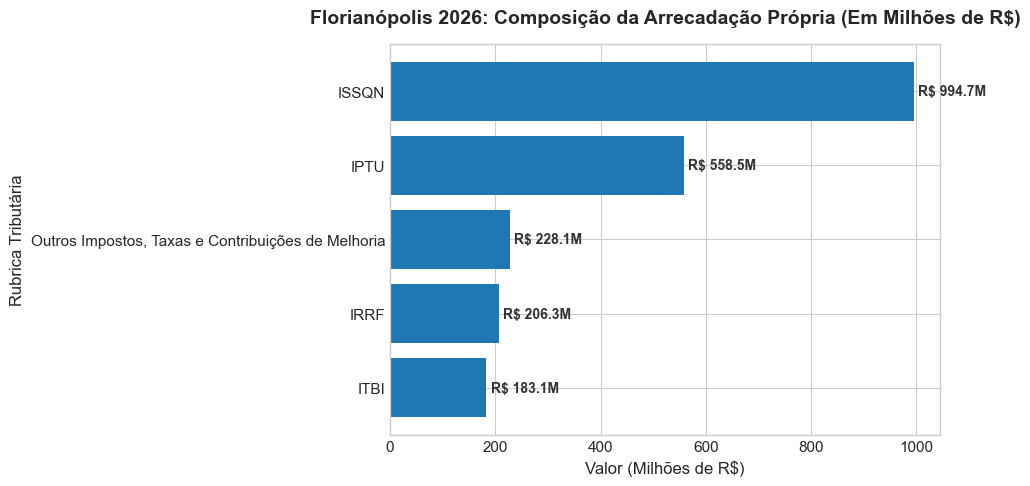

In [40]:
# Filtrando apenas impostos específicos arrecadados diretamente pelo município
impostos_especificos = df[
    (df['Categoria'] == 'Receitas Correntes') &
    (df['Subcategoria'] == 'Impostos, Taxas e Contribuições de Melhoria') &
    (df['Especificacao'] != 'Total da Categoria')
]

impostos_sorted = impostos_especificos.sort_values(by='Receita (R$)', ascending=True)

# Geração de Gráfico de Barras Horizontais
plt.figure(figsize=(10, 5))
bars = plt.barh(impostos_sorted['Especificacao'], impostos_sorted['Receita (R$)'] / 1e6, color='#1f77b4', edgecolor='none')
plt.title('Florianópolis 2026: Composição da Arrecadação Própria (Em Milhões de R$)', fontweight='bold', pad=15)
plt.xlabel('Valor (Milhões de R$)')
plt.ylabel('Rubrica Tributária')

# Adicionando rótulos de valores nas extremidades das barras
for bar in bars:
    width = bar.get_width()
    plt.text(width + 8, bar.get_y() + bar.get_height()/2, f'R$ {width:.1f}M', 
             va='center', ha='left', fontsize=10, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()


## 4. Composição das Receitas Correntes: Autonomia vs. Dependência

Compara a arrecadação própria com as transferências correntes (FPM/ICMS/FUNDEB) e as demais
receitas correntes, evidenciando o grau de dependência financeira do município por meio de
um gráfico de pizza.


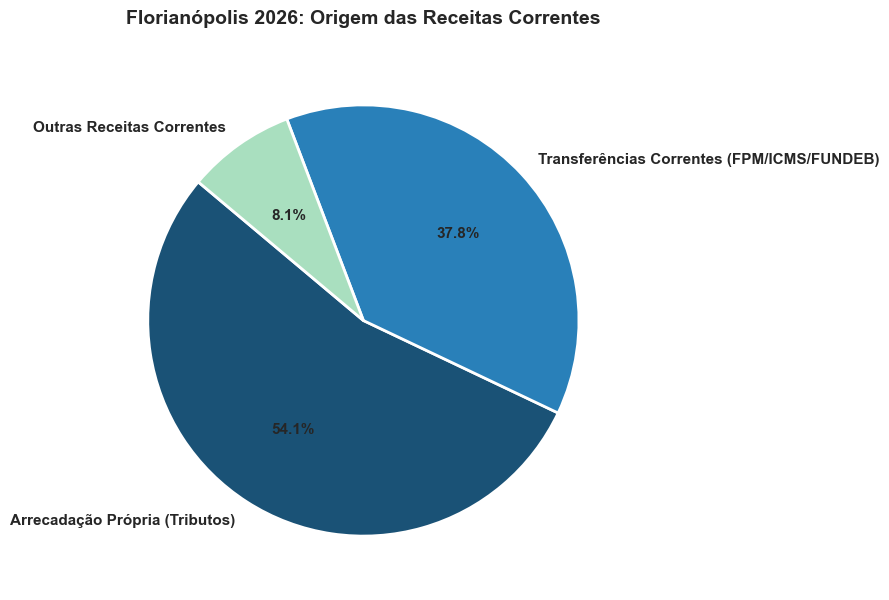

In [36]:
rec_propria = df[(df['Categoria'] == 'Receitas Correntes') & (df['Subcategoria'] == 'Impostos, Taxas e Contribuições de Melhoria') & (df['Especificacao'] == 'Total da Categoria')]['Receita (R$)'].values[0]
rec_transferencias = df[(df['Categoria'] == 'Receitas Correntes') & (df['Subcategoria'] == 'Transferências Correntes') & (df['Especificacao'] == 'Total da Categoria')]['Receita (R$)'].values[0]

# Agrupando outras fontes menores de receita corrente
outras_rec_correntes = df[(df['Categoria'] == 'Receitas Correntes') & 
                          (~df['Subcategoria'].isin(['Impostos, Taxas e Contribuições de Melhoria', 'Transferências Correntes'])) & 
                          (df['Especificacao'] == 'Total da Categoria')]['Receita (R$)'].sum()

labels_rec = ['Arrecadação Própria (Tributos)', 'Transferências Correntes (FPM/ICMS/FUNDEB)', 'Outras Receitas Correntes']
valores_rec = [rec_propria, rec_transferencias, outras_rec_correntes]
colors_rec = ['#1a5276', '#2980b9', '#a9dfbf']

# Plotagem do Gráfico de Pizza
plt.figure(figsize=(7, 7))
plt.pie(valores_rec, labels=labels_rec, autopct='%1.1f%%', startangle=140, colors=colors_rec, 
        textprops={'fontsize': 11, 'fontweight': 'bold'}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Florianópolis 2026: Origem das Receitas Correntes', fontsize=14, pad=20, fontweight='bold')
plt.show()


## 5. Análise da Rigidez de Despesa (Asfixia de Investimentos)

Consolida as despesas obrigatórias — pessoal, custeio, juros da dívida, investimentos e
reserva de contingência — e demonstra sua distribuição em um gráfico de pizza, revelando
o espaço remanescente para investimentos.


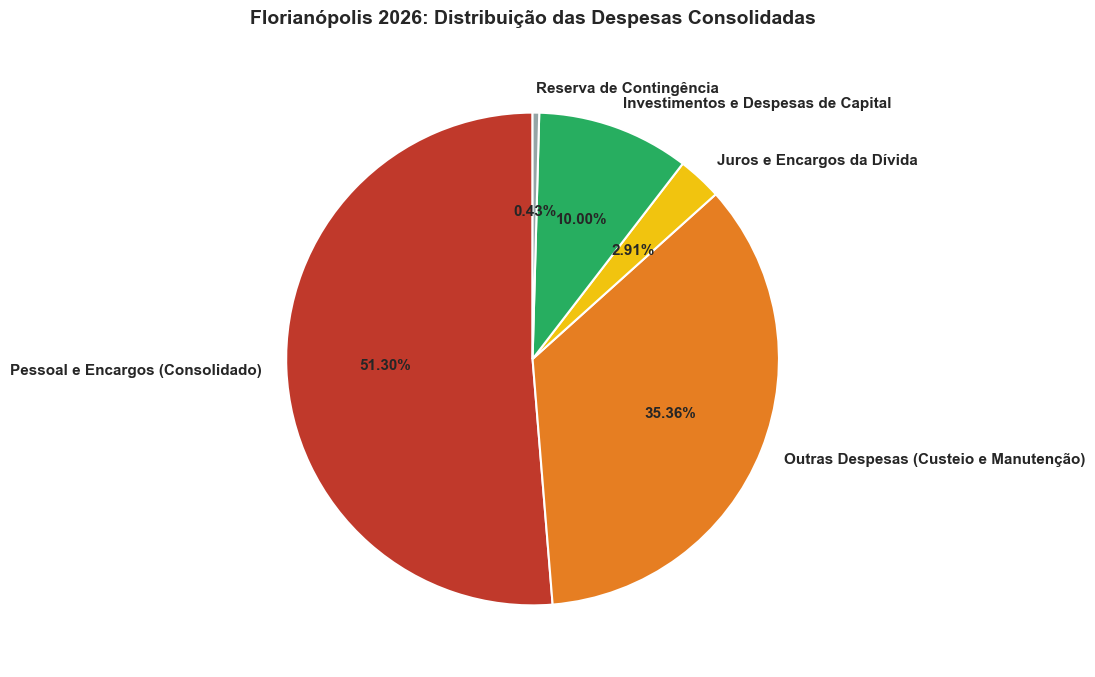

In [37]:
# Consolidação das despesas obrigatórias de pessoal (Direta + Intra-Orçamentária)
pessoal_direto = df[(df['Categoria'] == 'Despesas Correntes') & (df['Subcategoria'] == 'Pessoal e Encargos Sociais')]['Despesa (R$)'].values[0]
pessoal_intra = df[(df['Categoria'] == 'Despesas Intra-Orçamentárias') & (df['Especificacao'] == 'Pessoal e Encargos Sociais Intra-Orçamentária')]['Despesa (R$)'].values[0]
folha_consolidada = pessoal_direto + pessoal_intra

# Custeio operacional consolidado (Outras Despesas Correntes + outras parcelas Intra)
outras_correntes = df[(df['Categoria'] == 'Despesas Correntes') & (df['Subcategoria'] == 'Outras Despesas Correntes')]['Despesa (R$)'].values[0]
outras_intra = df[(df['Categoria'] == 'Despesas Intra-Orçamentárias') & (df['Especificacao'] != 'Pessoal e Encargos Sociais Intra-Orçamentária') & (df['Despesa (R$)'] > 0)]['Despesa (R$)'].sum()
outros_custeios = outras_correntes + outras_intra

# Demais despesas agregadas
juros_divida = df[(df['Categoria'] == 'Despesas Correntes') & (df['Subcategoria'] == 'Juros e Encargos da Dívida')]['Despesa (R$)'].values[0]
investimentos_capital = df[(df['Categoria'] == 'Despesas de Capital') & (df['Subcategoria'] == 'Total Despesas de Capital')]['Despesa (R$)'].values[0]
reserva_contingencia = df[(df['Categoria'] == 'Reserva de Contingência')]['Despesa (R$)'].values[0]

labels_desp = [
    'Pessoal e Encargos (Consolidado)', 
    'Outras Despesas (Custeio e Manutenção)', 
    'Juros e Encargos da Dívida', 
    'Investimentos e Despesas de Capital', 
    'Reserva de Contingência'
]
valores_desp = [folha_consolidada, outros_custeios, juros_divida, investimentos_capital, reserva_contingencia]
colors_desp = ['#c0392b', '#e67e22', '#f1c40f', '#27ae60', '#95a5a6']

# Plotagem do Gráfico de Pizza de Despesas
plt.figure(figsize=(8, 8))
plt.pie(valores_desp, labels=labels_desp, autopct='%1.2f%%', startangle=90, colors=colors_desp,
        textprops={'fontsize': 11, 'fontweight': 'bold'}, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Florianópolis 2026: Distribuição das Despesas Consolidadas', fontsize=14, pad=20, fontweight='bold')
plt.show()


## 6. Simulador de Limites Legais da LRF para Municípios (Pessoal)

A Lei Complementar nº 101/2000 (LRF) limita os gastos com pessoal a **60% da Receita Corrente
Líquida (RCL)** para os Municípios, divididos entre o Executivo (**54%**) e o Legislativo (**6%**).

* **Limite de Alerta (90% do máximo = 54%)**: o Tribunal de Contas emite aviso quando o percentual
  ultrapassa este patamar (Art. 59, §1º, II da LRF).
* **Limite Prudencial (95% do máximo = 57%)**: veda a concessão de vantagens, reajustes, criação de
  cargos, novas contratações e horas extras (Art. 22, parágrafo único da LRF).
* **Limite Máximo (100% = 60%)**: ultrapassado, o ente deve eliminar o excedente em até dois
  quadrimestres, reduzindo ao menos um terço no primeiro (Art. 23 da LRF).

A base consolidada da LOA não discrimina as despesas por Poder; por isso o comparativo abaixo usa o
limite total do Município (60%). Com dados segregados, cada Poder deve ser avaliado contra o seu
próprio sub-limite (Executivo 54% / Legislativo 6%).


In [38]:
rcl = df[(df['Categoria'] == 'Receitas Correntes Líquidas') & (df['Especificacao'] == 'Total (I - II)')]['Receita (R$)'].values[0]
percentual_pessoal = (folha_consolidada / rcl) * 100

print("="*72)
print("     MONITORAMENTO DE CONFORMIDADE FISCAL - LEI DE RESPONSABILIDADE FISCAL")
print("="*72)
print(f" Ente: MUNICÍPIO | Base: LOA 2026 Consolidada (Executivo + Legislativo)")
print(f" Receita Corrente Líquida (RCL) Estimada: R$ {rcl:,.2f}")
print(f" Despesa Consolidada com Pessoal:         R$ {folha_consolidada:,.2f}")
print("-"*72)
print(f" PROPORÇÃO PESSOAL / RCL:                 {percentual_pessoal:.2f}%")
print("-"*72)

# Limites legais para MUNICÍPIOS (LC 101/2000 - LRF)
# Total do Município: 60% da RCL | Executivo: 54% | Legislativo: 6%
limite_alerta = 54.0     # 90% do limite máximo (Art. 59, §1º, II)
limite_prudencial = 57.0 # 95% do limite máximo (Art. 22, parágrafo único)
limite_maximo = 60.0     # 100% (Art. 19, III)

print(" REFERÊNCIAS LEGAIS - MUNICÍPIOS (Art. 19, 20, 22 e 59 da LRF):")
print(f"   Limite de Alerta  (90% do máximo):          {limite_alerta:.1f}%")
print(f"   Limite Prudencial (95% do máximo):         {limite_prudencial:.1f}%")
print(f"   Limite Máximo Total do Município (100%):   {limite_maximo:.1f}%")
print("   Sub-limites: Executivo 54,0% | Legislativo 6,0%")
print("-"*72)

# Verificação das balizas legais para municípios (base consolidada do ente)
if percentual_pessoal <= limite_alerta:
    print(" STATUS: CONFORMIDADE PLENA (Abaixo do limite de alerta)")
elif percentual_pessoal <= limite_prudencial:
    print(" STATUS: ATENÇÃO! Limite de Alerta Ultrapassado (Art. 59, §1º, II da LRF)")
elif percentual_pessoal <= limite_maximo:
    print(" STATUS: LIMITE PRUDENCIAL ATINGIDO! Aplicam-se restrições de novos gastos (Art. 22 da LRF)")
else:
    print(" STATUS: ILEGALIDADE! Limite máximo ultrapassado (Necessidade de exonerações e cortes)")
print("="*72)


     MONITORAMENTO DE CONFORMIDADE FISCAL - LEI DE RESPONSABILIDADE FISCAL
 Ente: MUNICÍPIO | Base: LOA 2026 Consolidada (Executivo + Legislativo)
 Receita Corrente Líquida (RCL) Estimada: R$ 3,901,724,131.00
 Despesa Consolidada com Pessoal:         R$ 2,301,627,373.00
------------------------------------------------------------------------
 PROPORÇÃO PESSOAL / RCL:                 58.99%
------------------------------------------------------------------------
 REFERÊNCIAS LEGAIS - MUNICÍPIOS (Art. 19, 20, 22 e 59 da LRF):
   Limite de Alerta  (90% do máximo):          54.0%
   Limite Prudencial (95% do máximo):         57.0%
   Limite Máximo Total do Município (100%):   60.0%
   Sub-limites: Executivo 54,0% | Legislativo 6,0%
------------------------------------------------------------------------
 STATUS: LIMITE PRUDENCIAL ATINGIDO! Aplicam-se restrições de novos gastos (Art. 22 da LRF)
